# Animating a Waving U.S. Flag Using Python
## A July 4th Coding Activity - Celebrating America's 250th Birthday 🇺🇸🎆

*Keeping human curiosity alive in the age of AI*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SumuduTennakoon/ComputingIsFun/blob/master/HolidayGreetings/animated_flag_July4th.ipynb)

#### Sumudu Tennakoon, PhD
#### www.datasciencefoundations.com
---


**What you will build:**

Learn more about the Flag of the United States: https://en.wikipedia.org/wiki/Flag_of_the_United_States

![Animated waving U.S. flag](us_flag.gif)

## Introduction

Two hundred fifty years ago, thirteen colonies dared to envision a new nation. What they built became more than a country; it grew into a engine for human progress. From Franklin’s kite experiment to Edison’s light bulb, from the Wright Flyer to the Moon landing, and from the transistor to the Internet, America’s story has been shaped by science, mathematics, and the courage to create what did not yet exist. Today, the United States remains at the forefront of artificial intelligence and quantum computing.

That engine has always run on one fuel: **curious minds that learn deeply and apply boldly.**

Today,  AI can write code and provide answers instantly. So why should we sharpen our own intelligence?  Because **understanding is not the same as simply having the answer**. When you grasp how a sine wave causes a flag to ripple in computer graphics or how a loop arranges 50 stars in a perfect grid, you gain something that no tool can offer: the ability to reason, verify, and create with intention.  Civilization moves forward when people think deeply, not when they outsource their minds. AI should assist us in building better things, but it should never replace the curiosity that drives human progress. In a world filled with instant answers, understanding is the most valuable skill you can develop.

> **In this activity, you are the architect. AI is the contractor.**  
> Before running each cell, predict what will happen - then check if you were right. Modify the parameters. Break things and fix them. That habit of questioning and experimenting is the same spark that powered every American breakthrough for 250 years.

The coming years will shape this nation and human civilization, just as the first 250 years were shaped by curious, forward-thinking individuals who keep asking *why*, *what if*, and how do we *make it better*.

**Stay curious. Keep thinking. Keep building.** 🇺🇸

---

### By the end of this tutorial, you will be able to:

* Use `matplotlib` and `numpy` to create and animate graphical shapes
* Apply sine wave mathematics to simulate realistic motion
* Understand `FuncAnimation` for frame-by-frame animation
* Strengthen Python fundamentals: loops, functions, and array operations
* Practice predicting, testing, and understanding - the core of computational thinking

## Step 1: Setting Up the Coding Environment

### Prerequisites
No prior experience with graphics or animation is required. Basic familiarity with Python variables, loops, and functions is helpful - but if you are new to Python, you can still follow along and learn as you go.

### Local Computer Setup
* VSCode or similar IDE for Python (https://code.visualstudio.com)
* Python >= 3.12 (https://www.python.org/downloads)

### Cloud Alternative:
* Google Colab Notebook (https://colab.research.google.com)

### Python Libraries
* `matplotlib` (visualization), `numpy` (numerical computing), `pillow` (saving animations as GIF)
```bash
pip install matplotlib numpy pillow
```

In [1]:
# Import Required Libraries
import numpy as np # for numerical computing
import matplotlib.pyplot as plt # plot canvas and functions
from matplotlib.patches import Polygon, Rectangle # add shapes to the image
import matplotlib.animation as animation # used later in the animation step

## Step 2: Drawing the Static Flag

We start by breaking the flag into simple geometric shapes placed on a canvas.

* The canvas uses a **normalized coordinate system** - x and y both range from 0 to 1, with `(0, 0)` at the bottom-left corner. This keeps the math clean regardless of screen size.
* A `for` loop draws all 13 stripes with alternating colors
* A single `Rectangle` represents the blue canton (the star field)

### 2.1 Flag Design Parameters

The U.S. flag has precise proportions defined by Executive Order 10834. We approximate them here:

- **13 stripes** - one for each of the original colonies
- **Canton height = 7 stripes** - the blue field covers the top 7 stripes
- **Canton width ≈ 0.4** - roughly 2/5 of the total flag width

> **Think:** If the canvas runs from 0 to 1 and there are 13 equal stripes, what is `stripe_height`? Calculate it before running the next cell.

<details><summary>Check your answer</summary>

`stripe_height = 1/13 ≈ 0.077` - thirteen equal stripes dividing a canvas of height 1.
</details>

In [2]:
# Flag design parameters
num_stripes = 13
stripe_height = 1 / num_stripes          # Even vertical division
canton_height = 7 * stripe_height        # Canton covers 7 stripes
canton_width = 0.4                       # Roughly 2/5 of flag width
rows, cols = 9, 11                       # Star rows & columns

### 2.2 Drawing on a Normalized Canvas

The canvas coordinate system places `(0, 0)` at the bottom-left and `(1, 1)` at the top-right:

```
(0,1)──────────(1,1)   ← top edge
  |                |
  |  flag canvas   |
  |                |
(0,0)──────────(1,0)   ← bottom edge
```

`ax.set_xlim(0, 1)` and `ax.set_ylim(0, 1)` define these bounds. Every shape we draw - stripes, canton, stars - is positioned using `(x, y)` coordinates within this unit space.

> **Before you run:** Stripe 0 is drawn at `y = 0` (the bottom). Based on the alternating color logic `'red' if i % 2 == 0 else 'white'`, will the bottom stripe be red or white?

<details><summary>Check your answer</summary>

Red - stripe 0 has an even index. And because 13 is odd, the top stripe (`i = 12`) is also red, exactly like the real flag: red at both top and bottom.
</details>

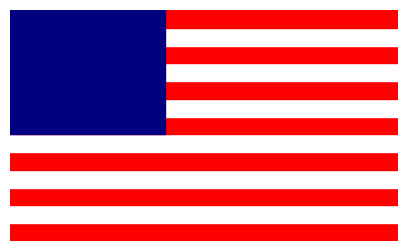

In [3]:
# Set up the canvas
fig, ax = plt.subplots(figsize=(5, 3)) # 3′ × 5′ flag
ax.set_xlim(0, 1)      # X-axis range from 0 to 1
ax.set_ylim(0, 1)      # Y-axis range from 0 to 1
ax.axis('off')         # Hide axes, we just want the flag

# Create Stripes
stripes = []
for i in range(num_stripes):
    color = 'red' if i % 2 == 0 else 'white' # Alternate red and white color when painting stripes
    stripe_start_coordinates = (0, i * stripe_height) # taking bottom left of the canvas as (0,0)
    stripe = Rectangle(xy=stripe_start_coordinates, width=1, height=stripe_height, color=color)
    ax.add_patch(stripe)
    stripes.append(stripe)

# Create Canton
canton_start_coordinates = (0, 1 - canton_height) # taking bottom left of the canvas as (0,0)
canton = Rectangle(xy=canton_start_coordinates, width=canton_width, height=canton_height, color='navy')
ax.add_patch(canton)

plt.show()

## Step 3: Drawing Stars

Adding the 50 stars - one for each state of the Union - introduce two new concepts:

* **Polar to Cartesian geometry** - converting angles and distances into `(x, y)` coordinates to trace the points of a star
* **Nested loops with a checkerboard condition** - placing stars in the staggered grid that matches the U.S. flag specification

In [4]:
# New Flag design parameter
star_size = 0.012                       # Star radius

### 3.1 Drawing a Star: Polar to Cartesian Geometry

A 5-pointed star is drawn by alternating between two circles - one large (outer points) and one small (inner concave points):

```
outer radius  →  ★  point tip
inner radius  →  · concave indent between points
```

Each point is computed from its **polar coordinates** (angle, radius) and converted to **Cartesian** (x, y):

```
x = cx + radius × cos(angle)
y = cy + radius × sin(angle)
```

We step through 10 equally spaced angles (5 outer, 5 inner), alternating between the two radii, then close the shape with one extra point - 11 total.

> **Before you read the code:** Why do we need 11 angles to define a 10-point star shape?

<details><summary>Check your answer</summary>

The 11th point repeats the first - angle 0 and angle 2π point in the same direction. It brings the outline back to its starting point so the polygon closes cleanly.
</details>

In [5]:
# Helper function to draw a 5-pointed star
def create_star(x_center, y_center, size):
    """
    Creates a 5-pointed star centered at (x_center, y_center).
    Returns a matplotlib Polygon object.
    """
    angles = np.linspace(0, 2 * np.pi, 11)  # 10 points (outer and inner), +1 to close the shape
    radius = np.array([size, size * 0.4] * 5 + [size])  # Alternate outer/inner radii
    # Convert polar coordinates to Cartesian (x, y)
    x = x_center + radius * np.cos(angles + np.pi / 2)
    y = y_center + radius * np.sin(angles + np.pi / 2)
    return Polygon(np.column_stack([x, y]), closed=True, color='white', zorder=4)

### 3.2 Placing Stars in a Staggered Grid

The U.S. flag has 50 stars in a staggered arrangement - alternating rows of 6 and 5. 

We approximate this using a **checkerboard condition** on a 9×11 grid:

```python
if (row + col) % 2 == 0:   # place a star only at even-sum positions
```

When the sum of a row and column index is even, we place a star. This selects positions in a diagonal pattern that creates the staggered effect.

> **Think:** How many stars does this condition place in a 9×11 grid? Work it out mathematically, then count the stars in the output to verify.  
> *(Hint: in a 9×11 grid of 99 cells, how many have an even row+col sum?)*

<details><summary>Check your answer</summary>

Exactly 50. The 5 even rows (0, 2, 4, 6, 8) each hold 6 stars, and the 4 odd rows each hold 5: 5 × 6 + 4 × 5 = 50 - one per state. That is precisely why the grid is 9×11.
</details>

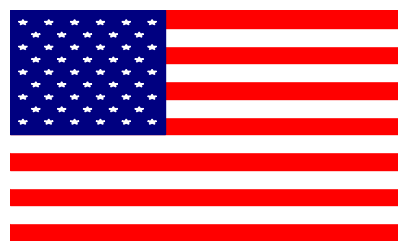

In [6]:
# Set up the canvas
fig, ax = plt.subplots(figsize=(5, 3)) # 3′ × 5′ flag
ax.set_xlim(0, 1)      # X-axis range from 0 to 1
ax.set_ylim(0, 1)      # Y-axis range from 0 to 1
ax.axis('off')         # Hide axes, we just want the flag

# Create Stripes
stripes = []
for i in range(num_stripes):
    color = 'red' if i % 2 == 0 else 'white' # Alternate red and white color when painting stripes
    stripe_start_coordinates = (0, i * stripe_height) # taking bottom left of the canvas as (0,0)
    stripe = Rectangle(xy=stripe_start_coordinates, width=1, height=stripe_height, color=color)
    ax.add_patch(stripe)
    stripes.append(stripe)

# Create Canton
canton_start_coordinates = (0, 1 - canton_height) # taking bottom left of the canvas as (0,0)
canton = Rectangle(xy=canton_start_coordinates, width=canton_width, height=canton_height, color='navy')
ax.add_patch(canton)

#------------------------------------------------------------------------------
# New Code: Create stars and store their base positions
#------------------------------------------------------------------------------
stars = []
for row in range(rows):
    for col in range(cols):
        if (row + col) % 2 == 0:  # Checkerboard pattern to match U.S. flag spec
            x = canton_width * (col + 1) / (cols + 1)
            y = 1 - canton_height * (row + 1) / (rows + 1)
            star = create_star(x, y, star_size)
            ax.add_patch(star)
            stars.append((star, x, y))  # Store shape and original position
#------------------------------------------------------------------------------

plt.show()

### 3.3: Converting Shapes for Animation

`Rectangle` stores only `x, y, width, height` - its shape is always axis-aligned and cannot be deformed.

To make stripes wave, each stripe must become a general quadrilateral whose top and bottom edges follow a sine curve. `Polygon` accepts an arbitrary list of vertex coordinates that we can update each animation frame using `set_xy()`. This is the key method that makes smooth animation possible.

**The trade-off:** `Polygon` requires us to manually specify all corner coordinates as arrays, which is more work upfront - but it gives us full control over the shape at every frame.

**About `zorder`:** When shapes overlap, `zorder` controls which one draws on top. Higher values appear in front. In our flag:
- Stripes: `zorder=1` (bottom layer)
- Canton: `zorder=2` (in front of stripes)
- Stars: `zorder=4` (in front of everything)

> **Note:** The output below looks identical to Step 3 - and it should. We changed the *internal representation* of each shape, not its appearance. The difference becomes visible in Step 4 when we start bending the shapes with a sine wave.

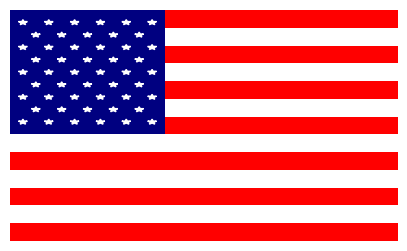

In [7]:
# Set up the canvas
fig, ax = plt.subplots(figsize=(5, 3)) # Proportional to 3′ × 5′ flag
ax.set_xlim(0, 1)      # X-axis range from 0 to 1
ax.set_ylim(0, 1)      # Y-axis range from 0 to 1
ax.axis('off')         # Hide axes, we just want the flag

#------------------------------------------------------------------------------
# Modified Code: Create Stripes as Polygons 
#------------------------------------------------------------------------------
stripes = []
for i in range(num_stripes):
    color = 'red' if i % 2 == 0 else 'white'
    y0 = i * stripe_height
    y1 = y0 + stripe_height

    # Four corners of the stripe
    coords = [(0, y0), (1, y0), (1, y1), (0, y1)]
    stripe = Polygon(coords, closed=True, facecolor=color, edgecolor='none')
    ax.add_patch(stripe)
    stripes.append(stripe)

# Create Canton as Polygon
y0 = 1 - canton_height
y1 = 1
x0 = 0
x1 = canton_width

# Four corners of the canton
canton_coords = [(x0, y0), (x1, y0), (x1, y1), (x0, y1)] 
canton = Polygon(canton_coords, closed=True, facecolor='navy', edgecolor='none')
ax.add_patch(canton)
#------------------------------------------------------------------------------

# Create stars and store their base positions
stars = []
for row in range(rows):
    for col in range(cols):
        if (row + col) % 2 == 0:  # Checkerboard pattern to match U.S. flag spec
            x = canton_width * (col + 1) / (cols + 1)
            y = 1 - canton_height * (row + 1) / (rows + 1)
            star = create_star(x, y, star_size)
            ax.add_patch(star)
            stars.append((star, x, y))  # Store shape and original position

plt.show()

## Step 4: Static Waving Flag

* Understand sine waves and their visual representations of amplitude, frequency, and phase
* Apply sine waves to polygon shapes

### 4.1 The Sine Wave

A sine wave is one of nature's most fundamental patterns. It describes ocean waves, sound vibrations, pendulums - and a flag rippling in the wind.

Three parameters control its shape:

| Parameter | What it controls | Flag analogy |
|---|---|---|
| `amplitude` | Height of the peaks | How hard the wind blows |
| `frequency` | Number of ripple cycles across the width | Gust spacing |
| `phase` | Horizontal shift of the wave | Where in the cycle we start |

**Formula:** `y = amplitude × sin(frequency × π × x − phase)`

> **Before you run:** With `amplitude = 0.01`, `frequency = 5`, `phase = 0` - how many peaks do you expect to see across the plot? Make a prediction, then run the cell.

<details><summary>Check your answer</summary>

`sin(5πx)` completes 2.5 full cycles between x = 0 and x = 1 - you will see 3 crests (at x = 0.1, 0.5, 0.9) and 2 troughs.
</details>

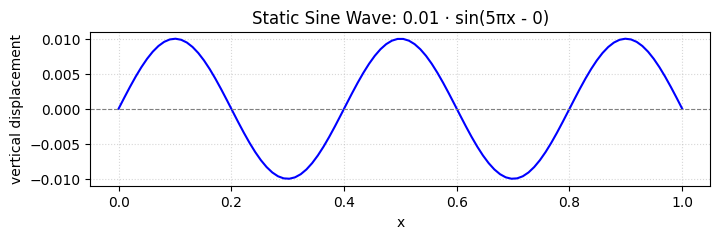

In [8]:
# Generate x-values for the grid
x_grid = np.linspace(0, 1, 100)

# Define phase
phase = 0  # Feel free to try other values like np.pi/2, np.pi, etc.

# Define amplitude
amplitude = 0.01

frequency = 5

# Compute sine wave
y_wave = amplitude * np.sin(frequency * np.pi * x_grid - phase)

# Plot
plt.figure(figsize=(8, 2))
plt.plot(x_grid, y_wave, color='blue')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title(f"Static Sine Wave: {amplitude} · sin({frequency}πx - {phase})")
plt.xlabel("x")
plt.ylabel("vertical displacement")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

**Experiment - change one parameter at a time and observe:**

- Set `frequency = 1`, then `frequency = 10`. What changes?
- Set `amplitude = 0.05`. What would this mean for the flag?
- Set `phase = np.pi / 2`. How does the wave shift left or right?
- **Challenge:** What value of `amplitude` would make adjacent stripes overlap? Calculate it first, then test it in Step 4.2.
  - *Hint: what is `stripe_height`?*

<details><summary>Check your answer (challenge)</summary>

Reasoning from the hint suggests `amplitude > stripe_height / 2 ≈ 0.038` - good thinking. But test it and watch closely: the stripes **never overlap**, no matter how large the amplitude! Every stripe is shifted by the *same* wave, so adjacent edges always move together. Overlap only becomes possible if each stripe gets a *different* wave - try the per-stripe phase offset in the Stretch Challenges at the end.
</details>

### 4.2 Applying the Wave to the Flag

Now we connect the math to the visual. Instead of drawing flat horizontal stripes, we add the sine wave as a **vertical displacement** to each stripe's edge coordinates.

Every point along a stripe's top and bottom edge gets shifted up or down by the wave value at that `x` position - bending the straight line into a curve. All stripes share the same wave, so they move together as one continuous surface.

> **Before you run:** The same wave is applied to every stripe from left to right. Do you expect the flag to look different on the left edge vs. the right edge? Why or why not?

<details><summary>Check your answer</summary>

They look the same. The wave completes whole cycles across the width, so the displacement is zero at both x = 0 and x = 1 - both edges of the flag stay level.
</details>

In [9]:
# New Flag design parameter for wavy flag
x_res = 100  # Horizontal resolution of sine wave for waving

In [ ]:
# Create horizontal base grid for wave shape
x_grid = np.linspace(0, 1, x_res)

# Wave parameters - the same three roles you explored in Section 4.1
amplitude = 0.01   # wave height
frequency = 4      # 4π across the width = 2 full cycles

wave = amplitude * np.sin(frequency * np.pi * x_grid)  # Sine wave shape

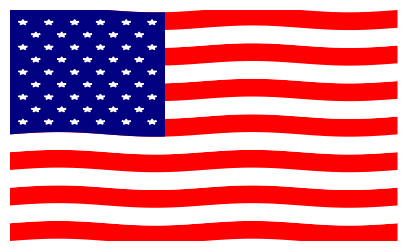

In [11]:
# Set up the canvas
fig, ax = plt.subplots(figsize=(5, 3)) # Proportional to 3′ × 5′ flag
ax.set_xlim(0, 1)      # X-axis range from 0 to 1
ax.set_ylim(0, 1)      # Y-axis range from 0 to 1
ax.axis('off')         # Hide axes, we just want the flag

# Create Stripes as Polygons 
stripes = []
for i in range(num_stripes):
    color = 'red' if i % 2 == 0 else 'white'

    #------------------------------------------------------------------------------
    # Modified Code: Make Polygon coordinates transform with sine wave
    #------------------------------------------------------------------------------
    y_base = i * stripe_height
    y0 = y_base + wave
    y1 = y0 + stripe_height

    # Build polygon by combining bottom and top edges
    x_full = np.concatenate([x_grid, x_grid[::-1]]) # x_grid[::-1] reverses x_grid for the top edge
    y_full = np.concatenate([y0, y1[::-1]])           # y1[::-1] reverses y1 for the top edge

    coordinates = np.column_stack([x_full, y_full]) # pair (x,y) coordinates from two arrays
    stripe = Polygon(xy=coordinates, closed=True, facecolor=color, edgecolor='none')
    #------------------------------------------------------------------------------
    ax.add_patch(stripe)
    stripes.append(stripe)

# Draw Wavy Canton as Polygon
x_canton = np.linspace(0, canton_width, x_res)

#------------------------------------------------------------------------------
# Modified Code: Make Polygon coordinates transform with sine wave
#------------------------------------------------------------------------------
wave_canton = amplitude * np.sin(frequency * np.pi * x_canton)  # same wave parameters as the stripes
y0_canton = 1 - canton_height + wave_canton
y1_canton = 1 + wave_canton

x_canton_full = np.concatenate([x_canton, x_canton[::-1]]) # x_canton[::-1] reverses x_canton for the top edge
y_full_canton = np.concatenate([y0_canton, y1_canton[::-1]]) # y1_canton[::-1] reverses y1_canton for the top edge

coordinates = np.column_stack([x_canton_full, y_full_canton]) # pair (x,y) coordinates from two arrays
canton_poly = Polygon(xy=coordinates, closed=True, facecolor='navy', edgecolor='none', zorder=2)
#------------------------------------------------------------------------------

ax.add_patch(canton_poly)

# Create stars and store their base positions
stars = []
for row in range(rows):
    for col in range(cols):
        if (row + col) % 2 == 0:  # Checkerboard pattern to match U.S. flag spec
            x = canton_width * (col + 1) / (cols + 1)
            y = 1 - canton_height * (row + 1) / (rows + 1)
            star = create_star(x, y, star_size)
            ax.add_patch(star)
            stars.append((star, x, y))  # Store shape and original position

plt.show()

## Step 5: Add Wave Animation to Flag

### How Animation Works

Think of a flip-book: a series of still images, each slightly different, played fast enough that the brain perceives smooth motion. `FuncAnimation` works exactly the same way - it calls a function once per **frame**, each call nudges the wave slightly, and played at speed the still frames become fluid motion.

We build the animation in three steps:

1. **Step 5.1** - Make the wave move: turn the sine formula into a function of time
2. **Step 5.2** - Make the shapes follow: write `animate()` to update every shape each frame
3. **Step 5.3** - Put everything together: one complete, standalone program

Then we play it (5.4) and save it as a `.gif` (5.5).

### 5.0 Animation Parameters

Two parameters control how the animation feels:

| Parameter | What it controls | Effect |
|---|---|---|
| `frame_count` | Total number of frames in the loop | More frames = longer, smoother loop |
| `interval` | Milliseconds between frames | Lower value = faster animation |

> **Think:** If `frame_count = 100` and `interval = 50` ms, how long does one full loop take in seconds?

<details><summary>Check your answer</summary>

100 frames × 50 ms = 5000 ms = 5 seconds per loop.
</details>

In [12]:
# New Flag design parameter for animation
frame_count = 100                        # Total frames in animation

### Step 5.1: Make the Wave Move

In Step 4 the wave was frozen - one fixed shape. To animate it, we wrap the same sine formula in a function that takes `phase` as an input:

```
displacement = amplitude × sin(frequency × π × x − phase)
```

Here `phase` plays the role of **time**. Increase it a little each frame and the whole wave slides horizontally across the flag - exactly like wind traveling through fabric. This is the only new math in Step 5; everything else is bookkeeping.

> **Predict:** What happens to the wave if `phase` increases by a *larger* amount each frame?

<details><summary>Check your answer</summary>

The wave travels faster - a bigger phase step per frame shifts the wave farther each time, so the ripples race across the flag. Make the step too big and the motion starts to look jumpy instead of smooth.
</details>

In [ ]:
# Sine wave generator (used by stripes and canton)
def sine_wave_generator(x_grid, phase, amplitude=0.01, frequency=5):
    """
    Returns a sine wave across the flag for the given animation phase.
    Simulates horizontal wind motion.
    amplitude - wave height; frequency - number of half-cycles (π) across the flag.
    """
    return amplitude * np.sin(frequency * np.pi * x_grid - phase)

### Step 5.2: Make the Shapes Follow the Wave

`animate(frame)` is the function `FuncAnimation` calls once per frame. Each call it:

1. Converts the frame number into a `phase` value (`phase = 0.1 * frame`)
2. Computes the new wave with `sine_wave_generator()`
3. Updates every shape's vertex coordinates with `set_xy()` - stripes, canton, and stars

Notice that `animate()` never creates new shapes - it only *moves* the existing ones. Even the stars keep their original `Polygon` objects; we just borrow `create_star()` to compute their new coordinates each frame.

`animate()` also reads variables it does not define - `stripes`, `canton_poly`, `stars`, and the coordinate grids. Python looks these up when the function is *called*, not when it is defined, so it is fine that they don't exist yet. They are created in Step 5.3, before `FuncAnimation` starts calling `animate()`.

In [ ]:
# Animation function: called once per frame by FuncAnimation
# Reads variables created in the setup cell (Step 5.3):
#   stripes, canton_poly, stars   - the patch objects to update
#   x_grid, x_canton, x_canton_full - the horizontal coordinate grids
#   stripe_height, canton_height  - flag geometry constants
def animate(frame):
    phase = 0.1 * frame  # Controls horizontal motion of the wave

    wave = sine_wave_generator(x_grid, phase)

    # Update each stripe's y-coordinates with the shared wave
    for i, poly in enumerate(stripes):
        y_base = i * stripe_height
        y_bottom = y_base + wave
        y_top = y_base + stripe_height + wave

        x_full = np.concatenate([x_grid, x_grid[::-1]])
        y_full = np.concatenate([y_bottom, y_top[::-1]])
        poly.set_xy(np.column_stack([x_full, y_full]))

    # Update canton using same shared wave (cropped to its width)
    wave_canton = sine_wave_generator(x_canton, phase)
    y_bottom = (1 - canton_height) + wave_canton
    y_top = 1 + wave_canton
    y_canton = np.concatenate([y_bottom, y_top[::-1]])
    canton_poly.set_xy(np.column_stack([x_canton_full, y_canton]))

    # Slightly wave the stars using sine/cosine for shimmer
    for star, base_x, base_y in stars:
        dx = 0.003 * np.sin(2 * np.pi * base_y - phase)
        dy = 0.003 * np.cos(2 * np.pi * base_x - phase)
        updated_star = create_star(base_x + dx, base_y + dy, star_size)
        star.set_xy(updated_star.get_xy())

### Step 5.3: Putting It All Together

The single cell below is the **complete program** - imports, parameters, all three functions, flag construction, and the animation call, assembled from everything you built in Steps 1–5.

The functions are repeated here deliberately, so this one cell stands alone:
copy it into a file named `us_flag.py`, uncomment the `plt.show()` line at the bottom, and run it with `python us_flag.py` - no notebook required.

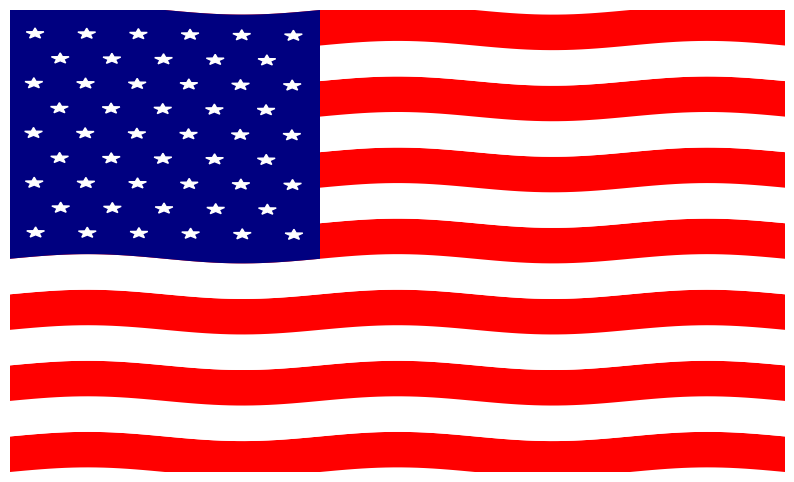

In [ ]:
# =============================================================================
# Waving U.S. Flag - the complete program in one cell
# Copy into a file named us_flag.py and run:  python us_flag.py
# =============================================================================

# --- Imports (Step 1) ---
import numpy as np                        # numerical computing
import matplotlib.pyplot as plt           # plot canvas and functions
from matplotlib.patches import Polygon    # add shapes to the image
import matplotlib.animation as animation  # frame-by-frame animation

# --- Flag design parameters (Step 2) ---
num_stripes = 13
stripe_height = 1 / num_stripes          # Even vertical division
canton_height = 7 * stripe_height        # Canton covers 7 stripes
canton_width = 0.4                       # Roughly 2/5 of flag width
rows, cols = 9, 11                       # Star rows & columns
star_size = 0.012                        # Star radius
x_res = 100                              # Horizontal resolution of the wave
frame_count = 100                        # Total frames in animation

# --- Helper function (Step 3): draw a 5-pointed star ---
def create_star(x_center, y_center, size):
    """
    Creates a 5-pointed star centered at (x_center, y_center).
    Returns a matplotlib Polygon object.
    """
    angles = np.linspace(0, 2 * np.pi, 11)  # 10 points (outer and inner), +1 to close the shape
    radius = np.array([size, size * 0.4] * 5 + [size])  # Alternate outer/inner radii
    # Convert polar coordinates to Cartesian (x, y)
    x = x_center + radius * np.cos(angles + np.pi / 2)
    y = y_center + radius * np.sin(angles + np.pi / 2)
    return Polygon(np.column_stack([x, y]), closed=True, color='white', zorder=4)

# --- Animation functions (Steps 5.1 and 5.2) ---
def sine_wave_generator(x_grid, phase, amplitude=0.01, frequency=5):
    """
    Returns a sine wave across the flag for the given animation phase.
    Simulates horizontal wind motion.
    amplitude - wave height; frequency - number of half-cycles (π) across the flag.
    """
    return amplitude * np.sin(frequency * np.pi * x_grid - phase)

def animate(frame):
    """Called once per frame by FuncAnimation - updates every shape."""
    phase = 0.1 * frame  # Controls horizontal motion of the wave

    wave = sine_wave_generator(x_grid, phase)

    # Update each stripe's y-coordinates with the shared wave
    for i, poly in enumerate(stripes):
        y_base = i * stripe_height
        y_bottom = y_base + wave
        y_top = y_base + stripe_height + wave

        x_full = np.concatenate([x_grid, x_grid[::-1]])
        y_full = np.concatenate([y_bottom, y_top[::-1]])
        poly.set_xy(np.column_stack([x_full, y_full]))

    # Update canton using same shared wave (cropped to its width)
    wave_canton = sine_wave_generator(x_canton, phase)
    y_bottom = (1 - canton_height) + wave_canton
    y_top = 1 + wave_canton
    y_canton = np.concatenate([y_bottom, y_top[::-1]])
    canton_poly.set_xy(np.column_stack([x_canton_full, y_canton]))

    # Slightly wave the stars using sine/cosine for shimmer
    for star, base_x, base_y in stars:
        dx = 0.003 * np.sin(2 * np.pi * base_y - phase)
        dy = 0.003 * np.cos(2 * np.pi * base_x - phase)
        updated_star = create_star(base_x + dx, base_y + dy, star_size)
        star.set_xy(updated_star.get_xy())

# --- Build the flag (Steps 2–3); shapes start flat, animate() bends them ---
x_grid = np.linspace(0, 1, x_res)

# Set up the canvas
fig, ax = plt.subplots(figsize=(10, 6)) # Proportional to 3′ × 5′ flag
ax.set_xlim(0, 1)      # X-axis range from 0 to 1
ax.set_ylim(0, 1)      # Y-axis range from 0 to 1
ax.axis('off')         # Hide axes, we just want the flag

# Create Stripes as Polygons
stripes = []
for i in range(num_stripes):
    color = 'red' if i % 2 == 0 else 'white'

    # Construct top and bottom edges flat (zero displacement)
    y_base = i * stripe_height
    x_full = np.concatenate([x_grid, x_grid[::-1]])  # Forward and reversed for top edge
    y_flat = np.concatenate([
        np.full_like(x_grid, y_base),                       # Bottom edge of stripe
        np.full_like(x_grid, y_base + stripe_height)[::-1]  # Top edge, reversed
    ])

    coordinates = np.column_stack([x_full, y_flat]) # pair (x,y) coordinates from two arrays
    stripe = Polygon(xy=coordinates, closed=True,
                     facecolor=color, edgecolor='none', zorder=1)
    ax.add_patch(stripe)
    stripes.append(stripe)

# Draw canton polygon (blue background for stars)
x_canton = np.linspace(0, canton_width, x_res) # evenly spaced horizontal points across the canton width
x_canton_full = np.concatenate([x_canton, x_canton[::-1]])
y_canton_flat = np.concatenate([
    np.full_like(x_canton, 1 - canton_height),  # Bottom of canton
    np.full_like(x_canton, 1)[::-1]             # Top of canton, reversed
])

coordinates = np.column_stack([x_canton_full, y_canton_flat]) # pair (x,y) coordinates from two arrays
canton_poly = Polygon(xy=coordinates, closed=True, facecolor='navy', edgecolor='none', zorder=2)
ax.add_patch(canton_poly)

# Create stars and store their base positions
stars = []
for row in range(rows):
    for col in range(cols):
        if (row + col) % 2 == 0:  # Checkerboard pattern to match U.S. flag spec
            x = canton_width * (col + 1) / (cols + 1)
            y = 1 - canton_height * (row + 1) / (rows + 1)
            star = create_star(x, y, star_size)
            ax.add_patch(star)
            stars.append((star, x, y))  # Store shape and original position

# --- Create the animation (Step 5) ---
ani = animation.FuncAnimation(fig, animate, frames=frame_count, interval=50)

# plt.show()   # Uncomment when running as a standalone .py script

## Step 5.4: Play the Animation

In a standard Python script, `plt.show()` opens an interactive window. Inside a Jupyter notebook we use `.to_jshtml()` instead - it converts the animation into a self-contained HTML player that runs directly in the browser, with no extra software needed.

> **Look for:**
> - Do the stripes and canton move together as one continuous surface?
> - Do the stars shimmer slightly as the flag waves?
> - Which direction does the wave appear to travel - and what in the code controls that?

In [ ]:
from IPython.display import HTML

ani = animation.FuncAnimation(fig, animate, frames=100, interval=50)
HTML(ani.to_jshtml())

## Step 5.5: Save the Animation

We can export the animation as a `.gif` file to share or embed anywhere - no Python or Jupyter required to view it.

Two parameters control the output:

| Parameter | What it does |
|---|---|
| `writer='pillow'` | Uses the Pillow image library to encode each frame into GIF format |
| `fps=20` | Frames per second - higher means smoother but larger file size |

> **Think:** The animation was created with `interval = 50` ms between frames (20 fps). If you save with `fps = 10`, how will the saved `.gif` look compared to what you saw in the notebook?

<details><summary>Check your answer</summary>

The same 100 frames play at half the rate - the gif lasts about 10 seconds and the flag appears to wave in slow motion (and slightly less smoothly).
</details>

In [17]:
# Save Animation as a .gif file
ani.save('us_flag.gif', writer='pillow', fps=20)

## Section 6: The 250th Birthday Edition 🎆🇺🇸

The flag waves - now let's make it a celebration. In this section we add two festive upgrades, and here is the point: **you already know all the math they need.**

| Upgrade | Reuses |
|---|---|
| **6.1** An anniversary banner that fades in | Frame-based animation from Step 5, plus one new idea: alpha (transparency) |
| **6.2** Fireworks bursting above the flag | The polar-to-Cartesian math from Step 3 - the same formula that drew the stars |

And a fitting detail: the show fires **250 sparks** in total - one for each year since 1776.

### 6.1 The Anniversary Banner

The first upgrade is text that fades in above the flag: **"1776 – 2026 • Celebrating 250 Years"**.

Two new ideas, both small:

- **Text is an artist too.** `ax.text()` returns an object just like `Polygon` - it can be placed, styled, and updated each frame the same way.
- **Fading = animating alpha.** `alpha` controls transparency, from 0 (invisible) to 1 (solid). Fade-in is one line per frame:

```python
banner.set_alpha(min(frame / 30, 1.0))
```

> **Think:** Why is the `min(..., 1.0)` needed? What would happen at frame 60 without it?

<details><summary>Check your answer</summary>

Without `min`, frame 60 would give `alpha = 2.0` - and matplotlib raises an error for alpha values outside 0–1. `min` caps the fade at fully opaque, so the banner fades in over 30 frames and then simply stays visible.
</details>

### 6.2 Fireworks - Polar Coordinates, One More Time 🎆

A firework burst is sparks flying outward from a center point in every direction - which is exactly the polar-to-Cartesian math from `create_star()`, used one more way:

```
x = cx + r × cos(angle)
y = cy + r × sin(angle)
```

The only difference: for the star, the radius was *fixed per point*. For a firework, the radius **grows with time** while the brightness **fades**:

| Per frame | Effect |
|---|---|
| `r = speed × t` | Sparks fly outward |
| `alpha = 1 − t / lifetime` | Burst fades to nothing |

We fire **5 bursts × 50 sparks = 250 sparks** - one for every year since 1776.

> **Before you run the preview:** The spark angles use `np.linspace(0, 2π, 50, endpoint=False)`. For the star we *included* the endpoint (11 points for 10 angles). Why exclude it here?

<details><summary>Check your answer</summary>

The star is an *outline* - it must return to its starting point to close the polygon. The sparks are separate *points* - angle 2π is the same direction as angle 0, so including the endpoint would just draw two sparks on top of each other and waste one of our 50.
</details>

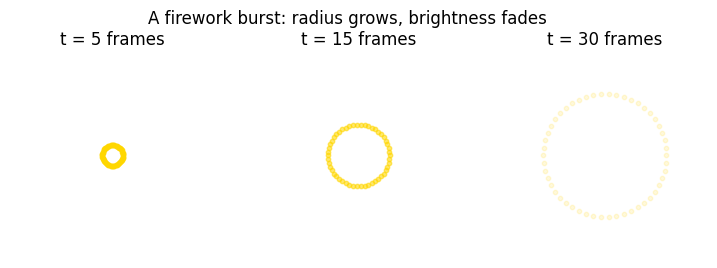

In [18]:
# Preview: one firework burst at three moments in time
n_sparks = 50
angles = np.linspace(0, 2 * np.pi, n_sparks, endpoint=False)

fig_preview, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax_p, t in zip(axes, [5, 15, 30]):
    r = 0.003 * t                    # radius grows with time
    xs = 0.5 + r * np.cos(angles)    # polar → Cartesian, same math as the stars
    ys = 0.5 + r * np.sin(angles)
    alpha = 1 - t / 35               # brightness fades with time
    ax_p.scatter(xs, ys, s=10, color='gold', alpha=alpha)
    ax_p.set_xlim(0.35, 0.65)
    ax_p.set_ylim(0.35, 0.65)
    ax_p.set_aspect('equal')
    ax_p.axis('off')
    ax_p.set_title(f"t = {t} frames")
plt.suptitle("A firework burst: radius grows, brightness fades")
plt.show()

### 6.3 The Complete Birthday Edition - Build, Play, and Save

The single cell below does everything: builds the scene, saves `us_flag_250.gif`, and plays the animation right in the notebook. Like Step 5.3, it is self-contained - to run it as a script, copy it into `us_flag_250.py`, remove the notebook-display lines at the bottom, and uncomment `plt.show()`.

New pieces to notice as you read:
- The canvas is taller (`ax.set_ylim(0, sky_top)`) - the flag keeps its 0–1 space, and the sky above holds the celebration
- The banner uses an *italic serif* face for an artistic touch - created invisible (`alpha=0.0`) and faded in by `animate()`
- Each firework is one `scatter` artist whose points and alpha are updated per frame
- Burst timing uses `(frame - start) % frame_count`, so the show loops seamlessly with the flag
- `plt.close(fig)` at the end suppresses the duplicate static frame, so only the animation player appears

> **Look for when it plays:**
> - The banner fading in over the first ~1.5 seconds
> - Each burst expanding outward while fading - 250 sparks in total across the loop
> - The bursts firing in sequence (staggered `start_frame` values), so the sky is never empty

In [ ]:
# =============================================================================
# Waving U.S. Flag - 250th Birthday Edition 🎆
# To run as a script: copy into us_flag_250.py, remove the notebook-display
# lines at the bottom, and uncomment plt.show()
# =============================================================================

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.animation as animation

# --- Flag design parameters (Step 2) ---
num_stripes = 13
stripe_height = 1 / num_stripes          # Even vertical division
canton_height = 7 * stripe_height        # Canton covers 7 stripes
canton_width = 0.4                       # Roughly 2/5 of flag width
rows, cols = 9, 11                       # Star rows & columns
star_size = 0.012                        # Star radius
x_res = 100                              # Horizontal resolution of the wave
frame_count = 100                        # Total frames in animation

# --- Celebration parameters (Section 6) ---
sky_top = 1.35                           # Canvas extends above the flag for the sky
BANNER_FADE_FRAMES = 30                  # Banner fades in over this many frames
N_SPARKS = 50                            # Sparks per firework burst
BURST_LIFE = 35                          # Frames each burst lives
SPARK_SPEED = 0.003                      # Radial growth per frame

# 5 bursts × 50 sparks = 250 sparks - one for each year 🎆
FIREWORKS = [
    # (x_center, y_center, start_frame, color)
    (0.20, 1.15,  0, 'gold'),
    (0.50, 1.22, 20, 'red'),
    (0.80, 1.12, 40, 'royalblue'),
    (0.35, 1.25, 60, 'red'),
    (0.65, 1.18, 80, 'gold'),
]

# --- Helper function (Step 3): draw a 5-pointed star ---
def create_star(x_center, y_center, size):
    """
    Creates a 5-pointed star centered at (x_center, y_center).
    Returns a matplotlib Polygon object.
    """
    angles = np.linspace(0, 2 * np.pi, 11)  # 10 points (outer and inner), +1 to close the shape
    radius = np.array([size, size * 0.4] * 5 + [size])  # Alternate outer/inner radii
    x = x_center + radius * np.cos(angles + np.pi / 2)
    y = y_center + radius * np.sin(angles + np.pi / 2)
    return Polygon(np.column_stack([x, y]), closed=True, color='white', zorder=4)

# --- Animation functions (Steps 5.1, 5.2, and Section 6) ---
def sine_wave_generator(x_grid, phase, amplitude=0.01, frequency=5):
    """
    Returns a sine wave across the flag for the given animation phase.
    Simulates horizontal wind motion.
    """
    return amplitude * np.sin(frequency * np.pi * x_grid - phase)

def animate(frame):
    """Called once per frame - updates the flag, the banner, and the fireworks."""
    phase = 0.1 * frame  # Controls horizontal motion of the wave

    wave = sine_wave_generator(x_grid, phase)

    # Update each stripe's y-coordinates with the shared wave
    for i, poly in enumerate(stripes):
        y_base = i * stripe_height
        y_bottom = y_base + wave
        y_top = y_base + stripe_height + wave

        x_full = np.concatenate([x_grid, x_grid[::-1]])
        y_full = np.concatenate([y_bottom, y_top[::-1]])
        poly.set_xy(np.column_stack([x_full, y_full]))

    # Update canton using same shared wave (cropped to its width)
    wave_canton = sine_wave_generator(x_canton, phase)
    y_bottom = (1 - canton_height) + wave_canton
    y_top = 1 + wave_canton
    y_canton = np.concatenate([y_bottom, y_top[::-1]])
    canton_poly.set_xy(np.column_stack([x_canton_full, y_canton]))

    # Slightly wave the stars using sine/cosine for shimmer
    for star, base_x, base_y in stars:
        dx = 0.003 * np.sin(2 * np.pi * base_y - phase)
        dy = 0.003 * np.cos(2 * np.pi * base_x - phase)
        updated_star = create_star(base_x + dx, base_y + dy, star_size)
        star.set_xy(updated_star.get_xy())

    # --- Section 6.1: Banner fades in over the first BANNER_FADE_FRAMES frames ---
    banner.set_alpha(min(frame / BANNER_FADE_FRAMES, 1.0))

    # --- Section 6.2: Fireworks - expanding, fading rings of sparks ---
    for scatter, (fx, fy, start, color), angles in fireworks:
        t = (frame - start) % frame_count   # burst timing loops with the animation
        if t < BURST_LIFE:
            r = SPARK_SPEED * t             # radius grows with time
            xs = fx + r * np.cos(angles)    # polar → Cartesian, same as the stars
            ys = fy + r * np.sin(angles)
            scatter.set_offsets(np.column_stack([xs, ys]))
            scatter.set_alpha(1.0 - t / BURST_LIFE)  # brightness fades with time
        else:
            scatter.set_alpha(0.0)          # burst is over - hide it

# --- Build the scene: flag (Steps 2–3) plus sky, banner, and fireworks ---
x_grid = np.linspace(0, 1, x_res)

fig, ax = plt.subplots(figsize=(10, 8))  # Taller canvas: flag + sky
ax.set_xlim(0, 1)
ax.set_ylim(0, sky_top)                  # 0–1 is the flag, above it is the sky
ax.axis('off')

# Create Stripes as Polygons (start flat; animate() bends them)
stripes = []
for i in range(num_stripes):
    color = 'red' if i % 2 == 0 else 'white'
    y_base = i * stripe_height
    x_full = np.concatenate([x_grid, x_grid[::-1]])
    y_flat = np.concatenate([
        np.full_like(x_grid, y_base),
        np.full_like(x_grid, y_base + stripe_height)[::-1]
    ])
    stripe = Polygon(xy=np.column_stack([x_full, y_flat]), closed=True,
                     facecolor=color, edgecolor='none', zorder=1)
    ax.add_patch(stripe)
    stripes.append(stripe)

# Draw canton polygon (blue background for stars)
x_canton = np.linspace(0, canton_width, x_res)
x_canton_full = np.concatenate([x_canton, x_canton[::-1]])
y_canton_flat = np.concatenate([
    np.full_like(x_canton, 1 - canton_height),
    np.full_like(x_canton, 1)[::-1]
])
canton_poly = Polygon(xy=np.column_stack([x_canton_full, y_canton_flat]),
                      closed=True, facecolor='navy', edgecolor='none', zorder=2)
ax.add_patch(canton_poly)

# Create stars and store their base positions
stars = []
for row in range(rows):
    for col in range(cols):
        if (row + col) % 2 == 0:
            x = canton_width * (col + 1) / (cols + 1)
            y = 1 - canton_height * (row + 1) / (rows + 1)
            star = create_star(x, y, star_size)
            ax.add_patch(star)
            stars.append((star, x, y))

# --- Section 6.1: The anniversary banner (starts invisible, fades in) ---
# Italic serif gives an artistic, engraved look and works on every platform.
# For a handwriting style, try fontfamily='cursive', or a font installed on
# your system (e.g. 'Brush Script MT' on Windows, 'Apple Chancery' on macOS).
banner = ax.text(0.5, 1.30, "1776 – 2026  •  Celebrating 250 Years",
                 ha='center', va='center', fontsize=20,
                 fontfamily='serif', fontstyle='italic', fontweight='bold',
                 color='darkgoldenrod', alpha=0.0, zorder=6)

# --- Section 6.2: One scatter artist per firework burst (start hidden) ---
fireworks = []
for fx, fy, start, color in FIREWORKS:
    angles = np.linspace(0, 2 * np.pi, N_SPARKS, endpoint=False)
    scatter = ax.scatter([], [], s=8, color=color, alpha=0.0, zorder=5)
    fireworks.append((scatter, (fx, fy, start, color), angles))

# --- Create the animation ---
ani = animation.FuncAnimation(fig, animate, frames=frame_count, interval=50)

# Save the birthday edition as a shareable .gif
ani.save('us_flag_250.gif', writer='pillow', fps=20)

# --- Notebook display (remove these lines in a .py script) ---
plt.close(fig)  # suppress the static frame - only the animation player shows
from IPython.display import HTML
HTML(ani.to_jshtml())

# plt.show()   # Uncomment when running as a standalone .py script

## Stretch Challenges

Try these after completing the tutorial. Each builds on what you have learned.

**Beginner**
- Make the flag wave faster (`interval = 20`) or slower (`interval = 100`)
- Increase `frame_count` to 200 - does the loop feel different?
- Change `amplitude` in `sine_wave_generator()` - what value makes the wave look unrealistic?

**Intermediate**
- The wave travels in one direction. How would you reverse it? *(Hint: look at the `phase` calculation in `animate()`)*
- Add a flagpole on the left: a narrow `Rectangle` from `x = -0.05` to `x = 0`
- Make the amplitude increase from left to right so the free end waves more than the pole end
- Add gravity to the fireworks: subtract a small `t²` term from each spark's `y` so the sparks arc downward as they fly

**Advanced**
- Replace the sine wave with two waves at different frequencies: `sin(5πx) + 0.5·sin(3πx)`. What does the flag look like?
- Give each stripe a slightly different phase offset so ripples travel across stripes, not just along them

**AI Collaboration Challenge**
- Ask an AI to "make the flag wave more realistically." Before accepting the output:
  - What math did it change?
  - Is the physics plausible - does a real flag behave this way?
  - Can you verify the code is correct by reading and reasoning through it yourself?

<hr/>

**Created:** 2025-07-04 by Sumudu Tennakoon  
**Last Updated:** 2026-07-04 - In celebration of America's 250th Birthday 🇺🇸🎆

*The original (2025) was developed from the author's original concept, with creative assistance from Microsoft Copilot, to support educational exploration and code assistance to create the Python code for visual output. The 2026 update was made with the assistance of [Claude Code](https://claude.ai/code) by Anthropic.*

<a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc-sa/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License</a>.